In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u


#Physical consts
mi_me = 1836.0 #electorn-ion mass ratio
k_B = 1.38e-23
mu0 = 4*np.pi*1e-7

#from 4/7/26 data on Space Weather Prediction Center
#maybe get a better number for n_i becasue mine was a guess but wont have much of a effect
n_i = 3e6 *u.m**-3 #ion density (m^-3) aproximation but right order of magnitude
B = 5e-9 *u.T#magnetic field
k_perp = np.logspace(-6, -3, 50) * u.rad / u.m



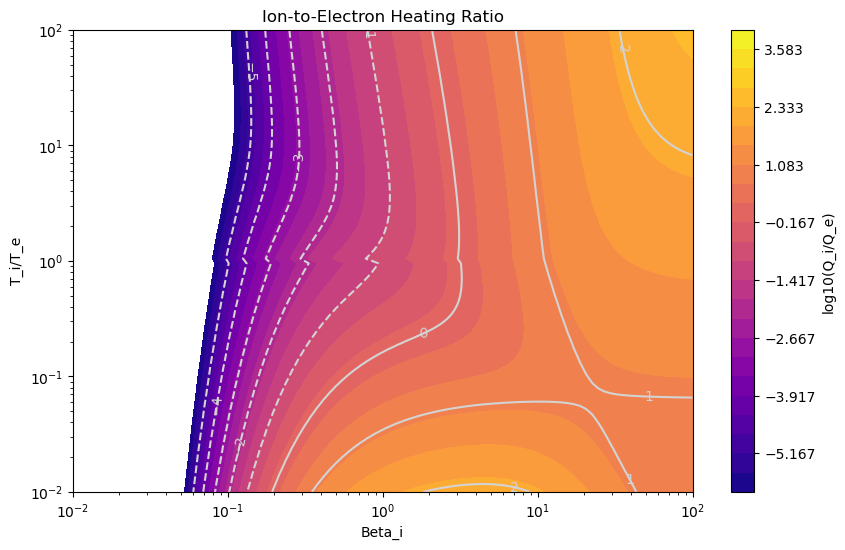

In [6]:
#Figure 1: Ion-to-Electron Heating Ratio FIT

#Parameter space
beta_i_grid = np.logspace(-2, 2, 100)  # dimensionless
Ti_Te  = np.logspace(-2, 2, 100)       # dimensionless
B, T = np.meshgrid(beta_i_grid, Ti_Te)

#Howes 2010 heating model coefficients
c1 = 0.92
c2 = np.where(T < 1, 1.2/T, 1.6/T)
c3 = np.where(T < 1, 18, 18 + 5*np.log10(T))
p  = 2 - 0.2*np.log10(T)

#ion to electron heating ratio
Qi_Qe = c1 * ((c2**2 + B**p)/(c3**2 + B**p)) * np.sqrt(T * mi_me) * np.exp(-1/B)
log_Qi_Qe = np.log10(Qi_Qe)


# Plotting
plt.figure(figsize=(10, 6))
cp = plt.contourf(B, T, log_Qi_Qe, levels=np.linspace(-6, 4, 25), cmap='plasma')
plt.colorbar(cp, label='log10(Q_i/Q_e)')

#==============================contours
line_contours = plt.contour(B, T, log_Qi_Qe, levels=np.arange(-5, 5, 1), colors='lightgrey')
plt.clabel(line_contours, inline=False, fontsize=10)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Beta_i')
plt.ylabel('T_i/T_e')
plt.title('Ion-to-Electron Heating Ratio')
plt.savefig('Howes(2010) Fit.png')
plt.show()
